# Week 6 — Generative Adversarial Networks
## Teaching Neural Networks to Create

**IIT Madras · Wadhwani School of AI**

---

**Session Plan (60 min):**
1. MLP GAN (~15 min) — Build Generator and Discriminator, train on MNIST, watch digits emerge
2. DCGAN (~15 min) — Conv-based GAN, sharper results, same adversarial game
3. Epoch Progression & Comparison (~5 min) — MLP vs DCGAN quality side-by-side
4. Q&A (~10 min)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import time

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch: {torch.__version__}")
print(f"Device: {device}")

PyTorch: 2.10.0+cpu
Device: cpu


### Data: MNIST Digits

We normalize to [-1, 1] because the Generator uses Tanh output (range [-1, 1]).

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])  # → [-1, 1] range
])

mnist = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
dataloader = DataLoader(mnist, batch_size=128, shuffle=True)

print(f"Dataset: {len(mnist):,} images, 28×28 grayscale")
print(f"Batches per epoch: {len(dataloader)}")

# Helper: show a grid of images
def show_images(images, title='', nrow=8):
    """Display a grid of generated images."""
    if isinstance(images, torch.Tensor):
        images = images.detach().cpu()
    grid = torchvision.utils.make_grid(images[:64], nrow=nrow, normalize=True, padding=1)
    plt.figure(figsize=(8, 8))
    plt.imshow(grid.permute(1, 2, 0).numpy(), cmap='gray')
    plt.title(title, fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.show()

100%|██████████| 9.91M/9.91M [00:00<00:00, 57.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.68MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.5MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.5MB/s]

Dataset: 60,000 images, 28×28 grayscale
Batches per epoch: 469


---
# Part 1: MLP GAN (~15 min)

The simplest GAN — both Generator and Discriminator are MLPs (fully connected layers). No convolutions yet.

### 1.1 Generator and Discriminator

**Generator**: 64-dim noise → 256 → 512 → 784 pixels (Tanh output for [-1,1] range).
**Discriminator**: 784 pixels → 256 → 128 → 1 probability (Sigmoid output).

In [ ]:
LATENT_DIM = 64   # Size of the random noise vector
IMG_SIZE = 28 * 28  # Flattened MNIST image

class MLPGenerator(nn.Module):
    """Maps random noise → fake image."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(LATENT_DIM, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, IMG_SIZE),
            nn.Tanh()  # Output in [-1, 1] to match normalized images
        )

    def forward(self, z):
        return self.net(z).view(-1, 1, 28, 28)


class MLPDiscriminator(nn.Module):
    """Classifies images as real (1) or fake (0)."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(IMG_SIZE, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 1),
            nn.Sigmoid()  # Output probability
        )

    def forward(self, x):
        return self.net(x)


mlp_G = MLPGenerator().to(device)
mlp_D = MLPDiscriminator().to(device)

print(f"Generator params:     {sum(p.numel() for p in mlp_G.parameters()):,}")
print(f"Discriminator params: {sum(p.numel() for p in mlp_D.parameters()):,}")

Generator params:     550,416
Discriminator params: 233,985


### Notebook Summary: Generative Adversarial Networks (GANs)

**1. Setup & Data (Cells 1-4)**
* **Environment**: Configures PyTorch and checks for GPU/CPU availability.
* **Dataset**: Loads MNIST digits and normalizes them to the range [-1, 1] to match the Generator's Tanh activation.
* **Visualization**: Defines a helper function `show_images` to display grids of generated or real digits.

**2. Part 1: MLP GAN (Cells 5-9)**
* **Architecture**: Implements a simple GAN using Fully Connected (Linear) layers.
    * **Generator**: Maps 64-dim noise to 784 pixels (28x28).
    * **Discriminator**: Classifies flattened 784-pixel images as real or fake.
* **Initial State**: Visualizes the 'garbage' output of an untrained generator.
* **Training Loop**: Defines `train_gan`, which handles the adversarial game (updating D to catch fakes, then updating G to fool D).

**3. Part 2: DCGAN (Cells 10-13)**
* **Architecture**: Implements a Deep Convolutional GAN.
    * **Generator**: Uses `ConvTranspose2d` to upsample noise into spatial structures.
    * **Discriminator**: Uses `Conv2d` to downsample images and extract features.
* **Goal**: Achieve sharper images by leveraging the spatial awareness of convolutional layers.

**4. Comparison & Export (Cells 14-18)**
* **Analysis**: Compares MLP and DCGAN results side-by-side.
* **Dynamics**: Plots training losses to show the 'tug-of-war' between the two networks.
* **Inference**: Demonstrates generating fresh samples from the trained models.
* **Persistence**: Saves the trained generator weights as `.pth` files.

### 1.2 What Random Noise Looks Like

Before training, the Generator just outputs garbage. Let's see what it produces from random noise.

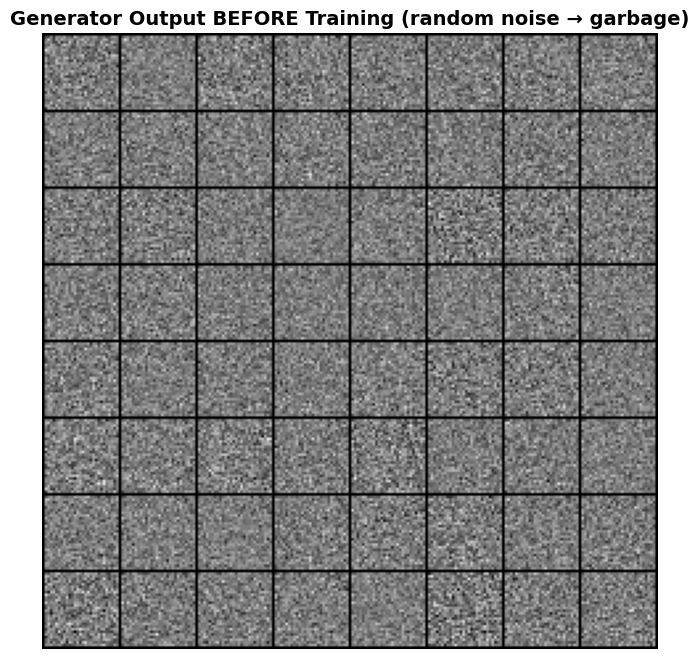

Current noise type used for display: Gaussian (torch.randn)
To use uniform noise, change `chosen_noise = fixed_noise_gaussian` to `chosen_noise = fixed_noise_uniform`.


In [ ]:
import torch

# Fixed noise for tracking progress across epochs
# Gaussian noise (standard normal distribution):
fixed_noise_gaussian = torch.randn(64, LATENT_DIM).to(device)

# Uniform noise (values between 0 and 1, then scaled if needed, or directly between -1 and 1 if using torch.rand*2-1):
# For this example, let's stick to the common practice where noise is often centered around 0.
# A simple way to get uniform noise between -1 and 1 is:
fixed_noise_uniform = (torch.rand(64, LATENT_DIM) * 2 - 1).to(device) # Uniform between [-1, 1]

# You can choose which one to use for the initial display
chosen_noise = fixed_noise_gaussian # Or fixed_noise_uniform

with torch.no_grad():
    fake_before = mlp_G(chosen_noise)

show_images(fake_before, 'Generator Output BEFORE Training (random noise → garbage)')

print("Current noise type used for display: Gaussian (torch.randn)")
print("To use uniform noise, change `chosen_noise = fixed_noise_gaussian` to `chosen_noise = fixed_noise_uniform`.")

### 1.3 The Adversarial Training Loop

Each batch: train D on real+fake images, then train G to fool D. Two separate 5-step loops per batch. We save generated images at each epoch to watch the progression.

In [ ]:
def train_gan(G, D, dataloader, fixed_noise, num_epochs=30, lr=0.0002):
    """Train a GAN and return loss histories + epoch samples."""
    criterion = nn.BCELoss()
    g_optimizer = optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
    d_optimizer = optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))

    g_losses, d_losses = [], []
    epoch_samples = {}  # Save generated images per epoch

    start = time.time()

    for epoch in range(num_epochs):
        epoch_g, epoch_d = 0, 0

        for real_images, _ in dataloader:
            batch_size = real_images.size(0)
            real_images = real_images.to(device)

            # Labels
            real_labels = torch.ones(batch_size, 1).to(device)
            fake_labels = torch.zeros(batch_size, 1).to(device)

            # ===== TRAIN DISCRIMINATOR =====
            # Real images → D should say 1
            real_out = D(real_images)
            d_loss_real = criterion(real_out, real_labels)

            # Fake images → D should say 0
            z = torch.randn(batch_size, LATENT_DIM).to(device)
            fake_images = G(z)
            fake_out = D(fake_images.detach())  # detach: don't update G here
            d_loss_fake = criterion(fake_out, fake_labels)

            d_loss = d_loss_real + d_loss_fake
            d_optimizer.zero_grad()     # 3. Zero grad
            d_loss.backward()           # 4. Backward
            d_optimizer.step()          # 5. Update D

            # ===== TRAIN GENERATOR =====
            # G wants D to think fakes are real → use real_labels
            z = torch.randn(batch_size, LATENT_DIM).to(device)
            fake_images = G(z)
            fake_out = D(fake_images)
            g_loss = criterion(fake_out, real_labels)  # "pretend fakes are real"

            g_optimizer.zero_grad()     # 3. Zero grad
            g_loss.backward()           # 4. Backward
            g_optimizer.step()          # 5. Update G

            epoch_g += g_loss.item()
            epoch_d += d_loss.item()

        avg_g = epoch_g / len(dataloader)
        avg_d = epoch_d / len(dataloader)
        g_losses.append(avg_g)
        d_losses.append(avg_d)

        # Save epoch samples
        G.eval()
        with torch.no_grad():
            epoch_samples[epoch + 1] = G(fixed_noise).detach().cpu()
        G.train()

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:2d}/{num_epochs} | D Loss: {avg_d:.4f} | G Loss: {avg_g:.4f}")

    elapsed = time.time() - start
    print(f"\nTraining complete in {elapsed:.1f}s")
    return g_losses, d_losses, epoch_samples

In [ ]:
MLP_EPOCHS = 30
print("Training MLP GAN...")
print("=" * 50)
mlp_g_losses, mlp_d_losses, mlp_samples = train_gan(
    mlp_G, mlp_D, dataloader, fixed_noise, num_epochs=MLP_EPOCHS
)

Training MLP GAN...


NameError: name 'fixed_noise' is not defined

### 1.4 Epoch-by-Epoch Progression

The Generator starts from pure noise and gradually learns to produce digit-like images. This is the key visual.

In [ ]:
def show_progression(epoch_samples, title_prefix='', checkpoints=None):
    """Show generated images at different epochs."""
    if checkpoints is None:
        total = max(epoch_samples.keys())
        checkpoints = [1, max(2, total//6), max(3, total//3), max(4, total//2),
                       max(5, 3*total//4), total]
        checkpoints = sorted(set(checkpoints))

    n = len(checkpoints)
    fig, axes = plt.subplots(1, n, figsize=(3 * n, 3))

    for ax, ep in zip(axes, checkpoints):
        if ep in epoch_samples:
            grid = torchvision.utils.make_grid(epoch_samples[ep][:16], nrow=4,
                                               normalize=True, padding=1)
            ax.imshow(grid.permute(1, 2, 0).numpy(), cmap='gray')
        ax.set_title(f'Epoch {ep}', fontsize=11, fontweight='bold')
        ax.axis('off')

    fig.suptitle(f'{title_prefix} — Generated Digits Over Training',
                 fontsize=14, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.show()

show_progression(mlp_samples, 'MLP GAN')
print("From noise to recognizable digits — the Generator learned without ever seeing real data.")
print("It only learned from the Discriminator's feedback.")

---
# Part 2: DCGAN — Convolutional GAN (~15 min)

The MLP GAN works but produces blurry images because it doesn't understand spatial structure. DCGAN uses the same Conv2d/ConvTranspose2d layers from weeks 3–4 to generate sharper results.

### 2.1 DCGAN Architecture

**Generator**: ConvTranspose2d upsamples noise from 1×1 → 7×7 → 14×14 → 28×28.
**Discriminator**: Conv2d downsamples images from 28×28 → 14×14 → 7×7 → 1 probability.

In [ ]:
class DCGenerator(nn.Module):
    """Convolutional Generator — upsamples noise to images."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            # Project noise to feature map: 64 → 256×7×7
            nn.Linear(LATENT_DIM, 256 * 7 * 7),
            nn.ReLU(True),
            nn.Unflatten(1, (256, 7, 7)),     # Reshape to 256×7×7

            # Upsample: 256×7×7 → 128×14×14
            nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            # Upsample: 128×14×14 → 1×28×28
            nn.ConvTranspose2d(128, 1, 4, stride=2, padding=1),
            nn.Tanh()  # [-1, 1]
        )

    def forward(self, z):
        return self.net(z)


class DCDiscriminator(nn.Module):
    """Convolutional Discriminator — classifies images."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            # 1×28×28 → 64×14×14
            nn.Conv2d(1, 64, 4, stride=2, padding=1),
            nn.LeakyReLU(0.2),

            # 64×14×14 → 128×7×7
            nn.Conv2d(64, 128, 4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            # 128×7×7 → 1
            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)


dc_G = DCGenerator().to(device)
dc_D = DCDiscriminator().to(device)

print(f"DC Generator params:     {sum(p.numel() for p in dc_G.parameters()):,}")
print(f"DC Discriminator params: {sum(p.numel() for p in dc_D.parameters()):,}")

# Shape check
test_z = torch.randn(1, LATENT_DIM).to(device)
test_img = dc_G(test_z)
print(f"\nGenerator: noise {test_z.shape} → image {test_img.shape}")
print(f"Discriminator: image {test_img.shape} → prob {dc_D(test_img).shape}")

In [ ]:
DCGAN_EPOCHS = 30
print("Training DCGAN...")
print("=" * 50)
dc_g_losses, dc_d_losses, dc_samples = train_gan(
    dc_G, dc_D, dataloader, fixed_noise, num_epochs=DCGAN_EPOCHS
)

In [ ]:
show_progression(dc_samples, 'DCGAN')
print("DCGAN produces sharper digits — conv layers understand spatial structure.")

---
# Part 3: Comparison & Analysis (~5 min)

Side-by-side: MLP GAN vs DCGAN — same training game, different architectures.

In [ ]:
# Final outputs side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (samples, title) in zip(axes, [
    (mlp_samples[MLP_EPOCHS], 'MLP GAN (Final)'),
    (dc_samples[DCGAN_EPOCHS], 'DCGAN (Final)'),
]):
    grid = torchvision.utils.make_grid(samples[:64], nrow=8, normalize=True, padding=1)
    ax.imshow(grid.permute(1, 2, 0).numpy(), cmap='gray')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.axis('off')

fig.suptitle('MLP GAN vs DCGAN — Same Number of Epochs',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print("DCGAN wins on sharpness. Conv layers give spatial understanding.")

In [ ]:
# Loss curves comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs_range = range(1, MLP_EPOCHS + 1)

axes[0].plot(epochs_range, mlp_d_losses, label='D Loss', color='#FB923C', linewidth=2)
axes[0].plot(epochs_range, mlp_g_losses, label='G Loss', color='#4ADE80', linewidth=2)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('MLP GAN Loss', fontweight='bold')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, dc_d_losses, label='D Loss', color='#FB923C', linewidth=2)
axes[1].plot(epochs_range, dc_g_losses, label='G Loss', color='#4ADE80', linewidth=2)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].set_title('DCGAN Loss', fontweight='bold')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

fig.suptitle('GAN Training Dynamics — D and G Push Each Other',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Healthy GAN training: D loss and G loss oscillate around each other.")
print("If D wins completely (D loss → 0), G stops learning (mode collapse).")
print("The balance between D and G is the key challenge.")

In [ ]:
# Interactive: generate new samples on demand
print("Generating fresh samples from both models...\n")

new_z = torch.randn(64, LATENT_DIM).to(device)

mlp_G.eval(); dc_G.eval()
with torch.no_grad():
    mlp_fresh = mlp_G(new_z)
    dc_fresh = dc_G(new_z)

show_images(mlp_fresh, 'MLP GAN — Fresh Samples (new noise)')
show_images(dc_fresh, 'DCGAN — Fresh Samples (same noise, different architecture)')

print("Same random noise, different generators.")
print("Every time you sample new z, you get new digits — infinite generation!")

### Model Saving

In [ ]:
torch.save(mlp_G.state_dict(), 'mlp_generator.pth')
torch.save(dc_G.state_dict(), 'dcgan_generator.pth')
print("Both generators saved.")

---
# Recap

### 1. GANs = Two Networks Playing a Game
- **Generator**: Noise → Fake Image (never sees real data)
- **Discriminator**: Image → Real or Fake (binary classifier)
- They train adversarially: G tries to fool D, D tries to catch G

### 2. The Training Loop is Two 5-Step Loops
```python
# Train D: real images → 1, fake images → 0
d_loss = BCE(D(real), 1) + BCE(D(G(z)), 0)
d_loss.backward() → d_optimizer.step()

# Train G: fool D → fakes should be labeled 1
g_loss = BCE(D(G(z)), 1)  # "pretend fakes are real"
g_loss.backward() → g_optimizer.step()
```

### 3. MLP vs DCGAN
- **MLP GAN**: Simple, works, but blurry (no spatial understanding)
- **DCGAN**: Conv layers produce sharper results (same Conv2d from week 3 + ConvTranspose2d from week 4)

### 4. Looking Ahead
GANs are the foundation. Modern generative models (Diffusion, VAEs) solve GAN's instability problems while keeping the core idea: learn to generate data, not just classify it.

---
*Questions?*